In [1]:
import os

os.environ["SCIPY_ARRAY_API"] = "1"

import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix



In [2]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance", # categorical
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

selected_features = [
    'VWF_HUMAN',
    'CRP_HUMAN',
    'AACT_HUMAN',
    'B2MG_HUMAN',
    'IBP3_HUMAN',
    'FIBG_HUMAN',
    'CYTC_HUMAN',
    'VCAM1_HUMAN',
    'LBP_HUMAN',
    'A2GL_HUMAN'
]

In [3]:
continuous_clinical_columns.extend(selected_features)

In [4]:

def preprocess_design_matrix(design_matrix):

    # design_matrix = design_matrix[
    #     ((design_matrix['Sepsis Diagnosis Probability'] >= 0.8) | 
    #     (design_matrix['Sepsis Diagnosis Probability'] <= 0.50))
    # ].copy()

    design_matrix['group'] = 1

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [5]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix.annotate()     


In [6]:
ms_data = pd.read_csv(
    "../0_data/proteins_test_filtered.tsv"
    , sep="\t"
)

In [7]:
design_matrix = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

In [8]:
ms_data_test = pd.read_csv(
    "../0_data/proteins_val_filtered.tsv"
    , sep="\t"
)
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_validation.tsv",
    sep='\t'
)

In [9]:
design_matrix['survival_30_day'] = np.where(design_matrix['survival_days'] <= 30, 1, 0)
design_matrix_test['survival_30_day'] = np.where(design_matrix_test['survival_days'] <= 30, 1, 0)


design_matrix['future_deterioration'] = np.where(
    design_matrix['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix['sofa_score_increase_day3'] > 1, 1, 0
    )
)

design_matrix_test['future_deterioration'] = np.where(
    design_matrix_test['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix_test['sofa_score_increase_day3'] > 1, 1, 0
    )
)

In [10]:
design_matrix_train = preprocess_design_matrix(design_matrix)

quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [11]:
quant_matrix_train_df = quant_matrix_train.to_df()
quant_matrix_train_df = quant_matrix_train_df[quant_matrix_train_df['ProteinLabel'].isin(selected_features)]

In [12]:
qm_filtered_train = (

    QuantMatrix(
        quantification_file=quant_matrix_train_df,
        design_matrix_file=design_matrix_train
    )

)

In [13]:
training_data, y = qm_filtered_train.to_ml(feature_column="ProteinLabel")

In [14]:
training_data = training_data.join(
    design_matrix_train.set_index("injection")
)

In [15]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer


In [16]:
design_matrix_test = preprocess_design_matrix(design_matrix_test)

quant_matrix_test = preprocess_data(ms_data_test, design_matrix=design_matrix_test)

In [17]:
quant_matrix_test_df = quant_matrix_test.to_df()
quant_matrix_test_df = quant_matrix_test_df[quant_matrix_test_df['ProteinLabel'].isin(selected_features)]

In [18]:
qm_filtered_test = (
    
    QuantMatrix(
        quantification_file=quant_matrix_test_df,
        design_matrix_file=design_matrix_test
    )
    
)

In [19]:
testing_data, y_test = qm_filtered_test.to_ml(feature_column="ProteinLabel")

In [20]:
testing_data = testing_data.join(
    design_matrix_test.set_index("injection")
)

In [21]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

clinical_scaler = StandardScaler()
protein_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])


In [22]:
training_data = training_data.reset_index(drop=True)

In [23]:
testing_data = testing_data.reset_index(drop=True)

In [24]:
from dfmodel import DigitalFamilyBinary

df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    neighbor_metric="euclidean",
    bootstrap_iterations=1000,
)

df_estimator.fit(training_data, features=selected_features)

In [25]:
training_data['Sepsis Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=False)
training_data['Infection Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="verified_infection", bootstrap=False)
training_data['Future Organ Dysfunction'] = df_estimator.predict(training_data, features=selected_features, target_column="future_deterioration", bootstrap=False)
training_data['30 Day Mortality'] = df_estimator.predict(training_data, features=selected_features, target_column="survival_30_day", bootstrap=False)

In [26]:
from fa2_modified import ForceAtlas2
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_

positions = nx.forceatlas2_layout(
    G,
    max_iter=10000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

In [27]:
display_columns = [
    "Sepsis Rates",
    "Infection Rates",
    "Future Organ Dysfunction",
    "30 Day Mortality",
]

In [28]:

def networkx_to_igraph(nx_graph):
    ig_graph = ig.Graph(directed=nx_graph.is_directed())
    ig_graph.add_vertices(list(nx_graph.nodes()))
    ig_graph.add_edges(list(nx_graph.edges()))

    # Optional: transfer node and edge attributes
    for node, attrs in nx_graph.nodes(data=True):
        for attr, value in attrs.items():
            ig_graph.vs[node][attr] = value

    for i, (u, v, attrs) in enumerate(nx_graph.edges(data=True)):
        for attr, value in attrs.items():
            ig_graph.es[i][attr] = value

    return ig_graph


In [41]:
import igraph as ig
import leidenalg as la

h = networkx_to_igraph(G)

In [42]:
partition = la.find_partition(
    h,
    la.RBConfigurationVertexPartition,
    resolution_parameter = 0.5
)

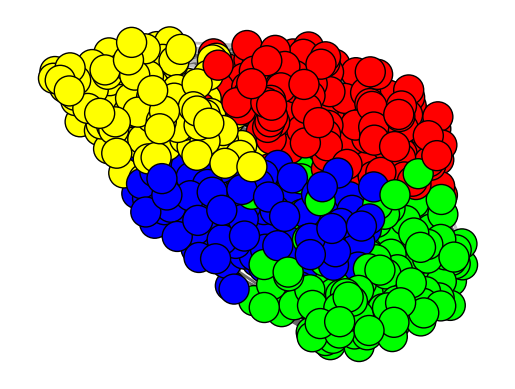

In [43]:

fig, ax = plt.subplots()

ig.plot(partition, target=ax)

In [44]:
training_data['Community'] = [partition.membership[v.index] for v in h.vs]

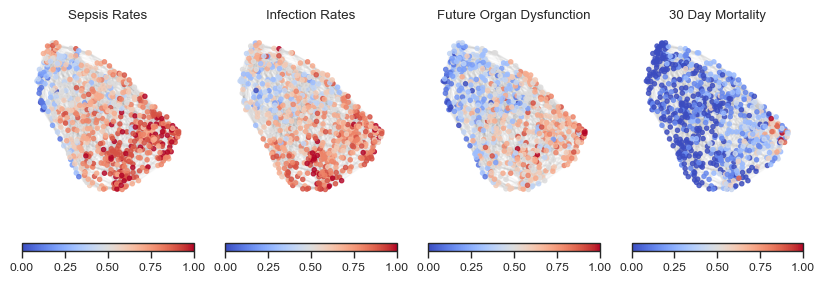

In [45]:
import matplotlib.pyplot as plt
sns.set_theme(font="Arial", style="white", context="paper")


fig, axs = plt.subplots(
    nrows=1,
    ncols=4
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(training_data[[col]])

    color_map = dict(zip(training_data.index, values))
    node_colors = [color_map[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)

    sm = plt.cm.ScalarMappable(cmap="coolwarm")
    cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

    #cbar = fig.colorbar(ax=axs[i])

fig.set_size_inches((8.27, 3))
plt.tight_layout()

(np.float64(-612.237255859375),
 np.float64(1207.155224609375),
 np.float64(-650.9965270996094),
 np.float64(626.9452575683594))

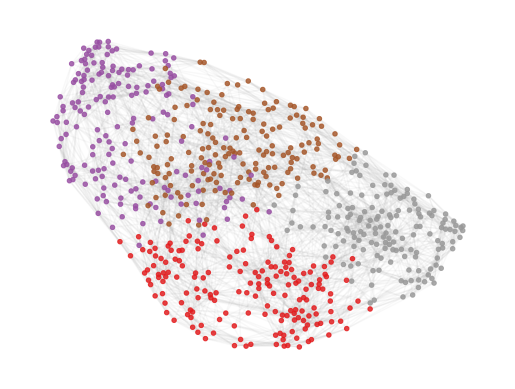

In [46]:
import matplotlib.pyplot as plt
sns.set_theme(font="Arial", style="white", context="paper")

fig, ax = plt.subplots()

values = training_data['Community'].to_list()

cmap = sns.color_palette("Set1", training_data['Community'].unique().shape[0])
color_map = dict(zip(training_data.index, values))
node_colors = [color_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="Set1", alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=ax)

ax.axis("off")

# sm = plt.cm.ScalarMappable(cmap="coolwarm")
# cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

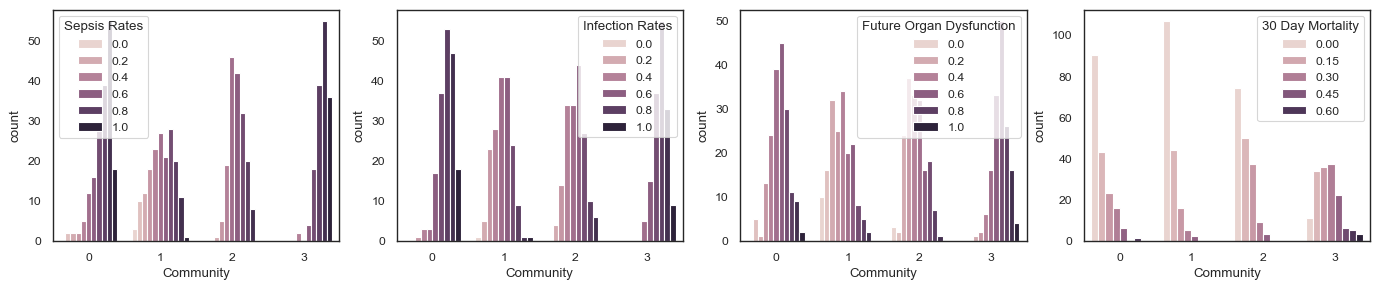

In [47]:

fig, axs = plt.subplots(
    nrows=1,
    ncols=4
)

for i, col in enumerate(display_columns):

    sns.countplot(
        data=training_data,
        x="Community",
        hue=col,
        ax=axs[i]
    )

fig.set_size_inches((17, 3))

(np.float64(-612.237255859375),
 np.float64(1207.155224609375),
 np.float64(-650.9965270996094),
 np.float64(626.9452575683594))

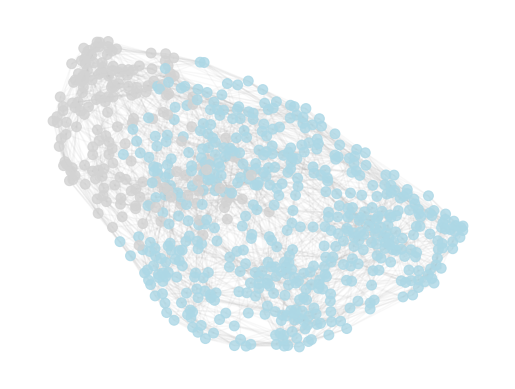

In [48]:
import matplotlib.pyplot as plt
sns.set_theme(font="Arial", style="white", context="paper")

fig, ax = plt.subplots()

values = np.where(training_data['Community'] == 1, 1, 0)

cmap = sns.color_palette(["#ADD8E6", "#D3D3D3"])
color_map = dict(zip(training_data.index, values))

node_colors = [cmap[color_map[i]] for i in G.nodes()]

nx.draw_networkx_nodes(G, positions, node_size=50, node_color=node_colors, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=ax)

ax.axis("off")

In [49]:
testing_data['Sepsis Rates'] = df_estimator.predict(testing_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=False)
testing_data['Infection Rates'] = df_estimator.predict(testing_data, features=selected_features, target_column="verified_infection", bootstrap=False)
testing_data['Future Organ Dysfunction'] = df_estimator.predict(testing_data, features=selected_features, target_column="future_deterioration", bootstrap=False)
testing_data['30 Day Mortality'] = df_estimator.predict(testing_data, features=selected_features, target_column="survival_30_day", bootstrap=False)

<Axes: xlabel='30 Day Mortality', ylabel='count'>

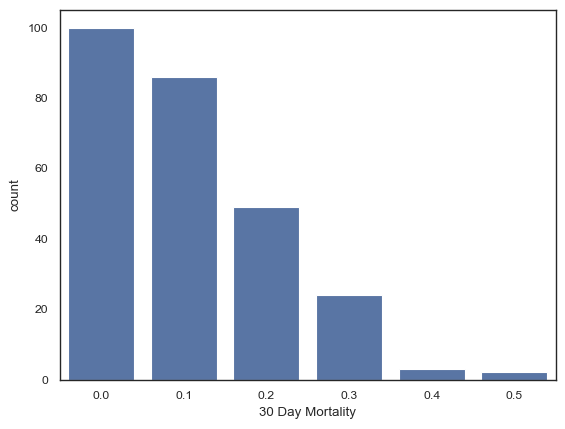

In [50]:
sns.countplot(
    data=testing_data,
    x="30 Day Mortality",
)

In [64]:
row['30 Day Mortality']

0.0

In [66]:
for idx, row in testing_data.iterrows():

    if row['30 Day Mortality'] > 0.2:

        sample_graph = df_estimator.model_sample(
            row,
            features=selected_features,
        )

        distances, neighbors = df_estimator.neighbors(
            pd.DataFrame([row]),
            features=selected_features,
        )

        neighbors = neighbors[0, :]
        distances = distances[0, :]

        neighborhood_positions = []

        for neighbor in neighbors:

            pos = positions[neighbor]

            neighborhood_positions.append(pos)

        neighborhood_positions = np.array(neighborhood_positions)

        centroid_position = neighborhood_positions.mean(axis=0)

        #TODO: Implement A* to find path to "safe zone"

        break

0.2
0.0
0.1
0.1
0.1
0.1
0.0
0.4
VWF_HUMAN                                   -1.221406
A2GL_HUMAN                                  -0.148859
FIBG_HUMAN                                  -0.568487
CRP_HUMAN                                    0.017866
IBP3_HUMAN                                   0.012151
                                      ...            
sample                      SA_BOX1_1915_S1-E9_1_4484
Sepsis Rates                                      0.7
Infection Rates                                   0.7
Future Organ Dysfunction                          0.8
30 Day Mortality                                  0.4
Name: 7, Length: 82, dtype: object


In [67]:
centroid_position

array([187.99097,  33.34948], dtype=float32)

In [68]:
new_positions = positions

In [69]:
new_positions[len(new_positions)] = centroid_position

In [70]:
training_data['source'] = "base"
training_data['size'] = 20

In [71]:
row['source'] = "query"
row['size']  = 100

In [72]:
combined = pd.concat(
    [training_data, pd.DataFrame([row])],
    ignore_index=True
)

In [73]:
nx.set_node_attributes(sample_graph, combined.to_dict(orient="index"))

In [74]:
combined.tail()

,VWF_HUMAN,A2GL_HUMAN,FIBG_HUMAN,CRP_HUMAN,IBP3_HUMAN,LBP_HUMAN,B2MG_HUMAN,VCAM1_HUMAN,AACT_HUMAN,CYTC_HUMAN,...,future_deterioration,group,sample,Sepsis Rates,Infection Rates,Future Organ Dysfunction,30 Day Mortality,Community,source,size
676,-0.449211,0.773169,-0.233424,0.018225,0.946659,0.819934,-0.442658,-0.640151,-0.512041,-1.845724,...,1,1,SA_BOX_7-2061_S4-H5_1_5946,0.6,0.8,0.4,0.0,0.0,base,20
677,0.037911,0.746386,1.110575,0.712995,0.372905,-0.000880,0.849833,0.547027,0.542622,1.146930,...,1,1,SA_BOX_2-764_S2-G2_1_6901,0.6,0.6,0.7,0.3,3.0,base,20
678,0.623011,2.305890,0.300801,1.253079,0.461945,2.188609,-0.104324,1.354294,0.701872,-0.278259,...,1,1,SA_BOX_6-774_S2-D10_1_5885,0.8,0.9,0.5,0.0,0.0,base,20
679,-0.395037,-1.185180,0.087523,-0.707024,-0.240829,0.294424,-0.272349,0.035558,0.403982,-0.276329,...,0,1,SA_BOX_4-1196_S5-A2_1_5621,0.6,0.7,0.4,0.0,2.0,base,20
680,-1.221406,-0.148859,-0.568487,0.017866,0.012151,-0.274511,0.181415,0.439387,0.396166,0.405466,...,1,1,SA_BOX1_1915_S1-E9_1_4484,0.7,0.7,0.8,0.4,NaN,query,100


In [75]:
positions

{0: array([-346.4369 ,  339.45032], dtype=float32),
 579: array([-361.8052 ,  307.05478], dtype=float32),
 321: array([-417.4671 ,  276.54562], dtype=float32),
 612: array([-250.57233,  323.96103], dtype=float32),
 631: array([-250.88365,  397.65494], dtype=float32),
 452: array([-177.54356,  360.55545], dtype=float32),
 613: array([-382.97272,  303.6167 ], dtype=float32),
 530: array([-213.87495,  370.5768 ], dtype=float32),
 198: array([-233.83806,  324.2393 ], dtype=float32),
 238: array([-262.78616,  307.5489 ], dtype=float32),
 92: array([-406.55496,  194.79872], dtype=float32),
 1: array([887.62463, -79.28815], dtype=float32),
 331: array([769.9523  , -11.579076], dtype=float32),
 453: array([893.7337 , -90.31694], dtype=float32),
 554: array([832.5062  , -19.531664], dtype=float32),
 228: array([ 858.4909 , -203.85797], dtype=float32),
 461: array([ 957.0072 , -172.85849], dtype=float32),
 160: array([ 764.9719, -179.0717], dtype=float32),
 330: array([819.1845  , -25.580889], d

In [76]:
centroid_position

array([187.99097,  33.34948], dtype=float32)

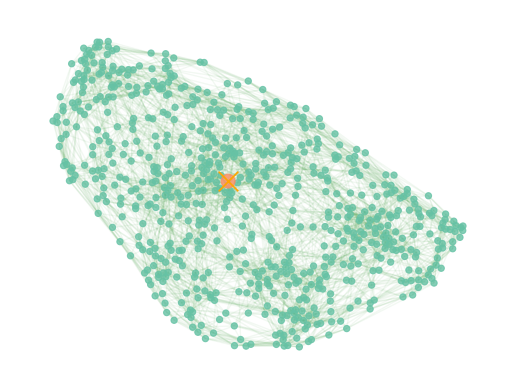

In [77]:
categories = combined['source'].unique()
palette = sns.color_palette('Set2', n_colors=len(categories))
category_color_map = dict(zip(categories, palette))

node_colors = [category_color_map[sample_graph.nodes[node]['source']] for node in sample_graph.nodes]

nx.draw_networkx_nodes(sample_graph, new_positions, node_size=combined['size'].to_list(), node_color=node_colors, alpha=0.8)

nx.draw_networkx_nodes(sample_graph, new_positions,
                       nodelist=[680],
                       node_size=200,
                       node_color='orange',
                       node_shape='x')

nx.draw_networkx_edges(sample_graph, positions, edge_color="green", alpha=0.05)
plt.axis('off')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt


X_test_results = pd.concat([X_test.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

fig, ax = plt.subplots()

protein_estimated_sepsis, protein_linregress_results, protein_predictions, protein_corr, protein_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)


sns.regplot(
    data=protein_estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    ax=ax,
    color="k"
)

ax.set_title(
    f"R2: {protein_linregress_results.rvalue:.2f}"
)

sns.despine()

In [ ]:
df_estimator = DigitalFamilyBinary()

df_estimator.fit(X_subset, features=clinical_columns)
X_test['Sepsis Protein Prob'] = df_estimator.predict(
    X_test[clinical_columns], 
    features=clinical_columns, 
    target_column="sepsis_or_septic_shock"
)


X_test_results = pd.concat([X_test.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

fig, ax = plt.subplots()

clinical_estimated_sepsis, clinical_linregress_results, clinical_predictions, clinical_corr, clinical_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)


sns.regplot(
    data=clinical_estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    ax=ax,
    color=".3",
    marker="x",
    line_kws=dict(color="k")
)

ax.set_title(
    f"R2: {clinical_linregress_results.rvalue:.2f}"
)

sns.despine()

In [ ]:
clinical_columns.extend(selected_features)
clinical_columns

In [ ]:
df_estimator = DigitalFamilyBinary()

df_estimator.fit(X_subset, features=clinical_columns)
X_test['Sepsis Protein Prob'] = df_estimator.predict(
    X_test[clinical_columns], 
    features=clinical_columns, 
    target_column="sepsis_or_septic_shock"
)

X_test_results = pd.concat([X_test.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

fig, ax = plt.subplots()

combined_estimated_sepsis, combined_linregress_results, combined_predictions, combined_corr, combined_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)

sns.regplot(
    data=combined_estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    ax=ax,
    color="k"
)

ax.set_title(
    f"R2: {combined_linregress_results.rvalue:.2f}"
)

sns.despine()

In [ ]:
combined_estimated_sepsis

In [ ]:
protein_estimated_sepsis['Label'] = "Protein"
clinical_estimated_sepsis['Label'] = "Clinical"
combined_estimated_sepsis['Label'] = "Combined"

In [ ]:
protein_estimated_sepsis['Predictions'] = protein_predictions
clinical_estimated_sepsis['Predictions'] = clinical_predictions
combined_estimated_sepsis['Predictions'] = combined_predictions
combined_estimated_sepsis

In [ ]:
# protein_estimated_s = protein_estimated_sepsis[['Estimated Sepsis Rate', 'Actual Sepsis Rate', 'Predictions']].groupby('Estimated Sepsis Rate').mean().reset_index()
# protein_estimated_s['Label'] = "Protein"

In [ ]:
# clinical_estimated_s = clinical_estimated_sepsis[['Estimated Sepsis Rate', 'Actual Sepsis Rate', 'Predictions']].groupby('Estimated Sepsis Rate').mean().reset_index()
# clinical_estimated_s['Label'] = "Clinical"

In [ ]:
# combined_estimated_s = combined_estimated_sepsis[['Estimated Sepsis Rate', 'Actual Sepsis Rate', 'Predictions']].groupby('Estimated Sepsis Rate').mean().reset_index()
# combined_estimated_s['Label'] = "Combined"

In [ ]:
estimated_sepsis = pd.concat(
    [
        protein_estimated_sepsis,
        clinical_estimated_sepsis,
        combined_estimated_sepsis
    ]
)
estimated_sepsis

In [ ]:
#fig, ax = plt.subplots()

sns.set_theme(context="paper", style="white")

g = sns.lmplot(
    data=estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    hue="Label",
    row="Label",
    ci=95,
    palette="mako",
    scatter_kws={"color": "gray", "alpha": 0.5, "s": 5},
    line_kws={"lw": "3"},
    #scatter_kws={'alpha': 0.1, 's': 5},
    scatter=True,
    x_ci=95,
    x_jitter=0.01,
    #s=100,
    #ax=ax
)

# sns.lineplot(
#     data=estimated_sepsis,
#     x='Estimated Sepsis Rate',
#     y="Predictions",
#     hue="Label",
#     palette="mako",
#     lw=2,
#     ax=ax
# )

#g.axes[0].axline((0, 0), slope=1, color='k', linestyle='--')

sns.despine()

# ax.set_title(
#     f"R2: {combined_linregress_results.rvalue:.2f}\n
#     "
# )

g.figure.set_size_inches((4, 3))


In [ ]:
g.figure.savefig(
    "digital_family_sepsis.pdf", dpi=300, bbox_inches="tight"
)

In [ ]:
estimated_sepsis.to_csv(
    "digital_family_sepsis.tsv",
    sep="\t",
    index=False
)